# 08 — Esperimento supplementare: stimare il SoH dalla ricarica

Tutta la pipeline principale ha un presupposto che in servizio non regge: che la capacità
sia misurata. Il SoH è definito come capacità su capacità iniziale, e per misurare la
capacità occorre scaricare completamente la cella in condizioni controllate. Su una
batteria in uso — un veicolo in strada, un accumulo in rete — quella scarica non si può
fare.

**La ricarica invece si osserva sempre.** Ogni volta che la cella viene caricata si
registrano tensione, corrente e temperatura, e da quella curva si possono ricavare
indicatori dello stato interno. La domanda di questo notebook è se bastino: non se siano
migliori di qualcos'altro, ma se da soli permettano di stimare lo stato di salute con un
errore utile.

**Il compito è diverso da quello della pipeline principale, e più difficile.** Lì il
modello prevede il SoH del ciclo successivo avendo negli ingressi il SoH dei cicli
precedenti: gran parte della risposta è già nota, e infatti il riferimento da battere è la
persistenza. Qui il SoH non compare fra gli ingressi in nessuna forma, né direttamente né
attraverso la capacità: il modello deve **stimarlo da zero** dalla firma della ricarica.
Non essendoci un valore precedente da ripetere, il riferimento diventa la media
dell'addestramento.

**Cosa contiene**

1. perché gli indicatori di ricarica dovrebbero trasferirsi meglio di quelli di scarica,
   e la verifica;
2. la stima del SoH dalla sola ricarica, con tre insiemi di variabili a confronto;
3. quale indicatore porta il segnale, e la sua interpretazione fisica;
4. se aggiungere la ricarica migliori anche il compito della pipeline principale.

**Input:** `data/processed/battery_cycles.csv`, prodotto dal notebook 01.

**Output**

| percorso | contenuto |
|---|---|
| `results/tables/08_carica_trasferibilita.csv` | copertura e scostamento degli indicatori |
| `results/tables/08_carica_stima.csv` | metriche della stima per insieme di variabili |
| `results/tables/08_carica_importanza.csv` | contributo dei singoli indicatori |
| `results/tables/08_carica_su_compito_principale.csv` | effetto sul compito del notebook 03 |
| `results/figures/08_*.png` | figure |


## 1. Configurazione


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except ImportError:
    pass


def find_project_root():
    candidate_paths = [
        Path("/content/drive/MyDrive/SoH_Neural_Tracker"),
        Path("/content/drive/My Drive/SoH_Neural_Tracker"),
        Path.cwd(), *Path.cwd().parents,
    ]
    for path in candidate_paths:
        if (path / "notebooks").exists() and (path / "data").exists():
            return path
    raise FileNotFoundError(
        "Cartella di progetto non trovata. Serve una directory SoH_Neural_Tracker "
        "contenente almeno notebooks/ e data/."
    )


PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
for cartella in [TABLES_DIR, FIGURES_DIR]:
    cartella.mkdir(parents=True, exist_ok=True)

WINDOW_SIZE = 10
LIMITE_SCOSTAMENTO = 5.0

SPLIT = {
    "train":      ["B0005_p1", "B0006_p1"],
    "validation": ["B0007_p1"],
    "test_id":    ["B0018_p1", "B0042_p1", "B0043_p1"],
    "test_ood":   ["B0029_p1", "B0030_p1", "B0031_p1", "B0032_p1",
                   "B0042_p2", "B0043_p2"],
}
INSIEMI = list(SPLIT)

percorso_cicli = DATA_PROCESSED / "battery_cycles.csv"
assert percorso_cicli.exists(), "manca battery_cycles.csv: esegui prima 01_preprocessing"

df = pd.read_csv(percorso_cicli)
df["soh_feature"] = df["soh"]

print("Radice del progetto:", PROJECT_ROOT)
print(f"Cicli: {len(df)}   validi: {int(df.is_valid.sum())}")


Mounted at /content/drive
Radice del progetto: /content/drive/MyDrive/SoH_Neural_Tracker
Cicli: 1020   validi: 926


## 2. Gli indicatori estratti dalla ricarica

Il protocollo di carica è a **corrente costante seguita da tensione costante**. Nella prima
fase la corrente resta al valore impostato e la tensione sale; raggiunto il limite la
tensione viene mantenuta e la corrente decade fino alla soglia di fine carica.

Le due fasi invecchiano in modo opposto, e questo è ciò che rende la curva informativa.
Una cella degradata accumula meno carica, quindi attraversa la finestra di tensione della
fase a corrente costante in **meno tempo**; al contempo la sua resistenza interna cresce, e
la coda a tensione costante si **allunga**. Due indicatori che si muovono in direzioni
opposte a partire dalla stessa causa.


In [2]:
INDICATORI_CARICA = [
    "cc_duration_s", "cv_duration_s", "cv_time_fraction", "cc_time_3v8_4v1_s",
    "charge_throughput_ah", "charge_cc_ah", "ica_peak_height", "ica_peak_voltage",
]
DESCRITTORI_SCARICA = [
    "voltage_mean", "voltage_min", "voltage_max", "voltage_std",
    "temperature_mean_rise", "temperature_max_rise", "temperature_std",
    "discharge_time", "num_measurements",
]

disponibili_carica = [c for c in INDICATORI_CARICA if c in df.columns]
assert disponibili_carica, (
    "il dataset non contiene indicatori di ricarica: verifica che il notebook 01 abbia "
    "eseguito la sezione sull'accoppiamento carica → scarica"
)

# Ogni indicatore esiste anche nella forma riferita all'inizio vita del blocco,
# costruita dal notebook 01 con la stessa logica con cui il SoH è rapportato alla
# capacità iniziale.
def in_forma_relativa(colonne):
    return [c + "_rel" for c in colonne if c + "_rel" in df.columns]


CARICA_REL = in_forma_relativa(disponibili_carica)
SCARICA_REL = in_forma_relativa(DESCRITTORI_SCARICA)

assert CARICA_REL, (
    "il dataset non contiene gli indicatori di ricarica riferiti all'inizio vita "
    "(colonne che finiscono in _rel). Riesegui 01_preprocessing: la sezione sui "
    "descrittori riferiti all'inizio vita li costruisce insieme a quelli di scarica."
)

print(f"Indicatori di ricarica disponibili: {len(disponibili_carica)}")
print(f"  in forma riferita a inizio vita: {len(CARICA_REL)}")
print(f"Descrittori di scarica riferiti:    {len(SCARICA_REL)}")

validi = df[df.is_valid]
completi = validi[disponibili_carica].notna().all(axis=1).sum()
print(f"\nCicli validi con ricarica completa: {completi} su {len(validi)}")
print("I cicli in cui manca un indicatore vengono esclusi: il tempo in corrente costante,")
print("ad esempio, richiede che la cella attraversi l'intera finestra di tensione.")


Indicatori di ricarica disponibili: 8
  in forma riferita a inizio vita: 8
Descrittori di scarica riferiti:    9

Cicli validi con ricarica completa: 902 su 926
I cicli in cui manca un indicatore vengono esclusi: il tempo in corrente costante,
ad esempio, richiede che la cella attraversi l'intera finestra di tensione.


## 3. Perché la ricarica dovrebbe trasferirsi meglio della scarica

Questa è l'ipotesi che rende l'esperimento interessante, e va verificata prima di
addestrare qualunque modello.

I descrittori di scarica dipendono dal protocollo di scarica, che nel dataset **cambia fra
i gruppi**: 2 A a 24 °C, 4 A a 43 °C, corrente diversa ancora a 4 °C. Un modello addestrato
su un protocollo vede valori fuori scala su un altro.

Il protocollo di **carica** è invece nominalmente lo stesso per tutte le celle: stessa
corrente, stessi limiti di tensione, stessa soglia di fine carica. Se fosse davvero
identico, gli indicatori sarebbero direttamente confrontabili fra celle e il problema del
trasferimento sparirebbe.

La verifica mostra che non è del tutto così, e il perché è fisico.


In [3]:
protocolli = (validi.groupby("protocol_block")
              .agg(ambiente_scarica=("ambient_temperature", "first"),
                   corrente_scarica=("current_mean", lambda s: round(float(s.abs().median()), 1)),
                   cc_durata_s=("cc_duration_s", "median"),
                   cv_durata_s=("cv_duration_s", "median"),
                   cc_tempo_finestra_s=("cc_time_3v8_4v1_s", "median"),
                   soh_mediano=("soh", "median"))
              .round(0).reset_index())
display(protocolli)

print("La ricarica avviene alla stessa temperatura ambiente della scarica, e la")
print("temperatura cambia la ripartizione fra le due fasi: al freddo la resistenza interna")
print("più alta fa salire prima la tensione, quindi la fase a corrente costante si")
print("accorcia e la coda a tensione costante si allunga. Gli indicatori assoluti")
print("ereditano quello scostamento anche se il protocollo impostato è identico.")


,protocol_block,ambiente_scarica,corrente_scarica,cc_durata_s,cv_durata_s,cc_tempo_finestra_s,soh_mediano
0,B0005_p1,24.0,2.0,3119.0,6725.0,1691.0,1.0
1,B0006_p1,24.0,2.0,2898.0,7557.0,1140.0,1.0
2,B0007_p1,24.0,2.0,3415.0,5853.0,1943.0,1.0
3,B0018_p1,24.0,2.0,3010.0,6779.0,1630.0,1.0
4,B0029_p1,43.0,4.0,3923.0,4163.0,2501.0,1.0
5,B0030_p1,43.0,4.0,3743.0,3619.0,2417.0,1.0
6,B0031_p1,43.0,4.0,3977.0,3847.0,2524.0,1.0
7,B0032_p1,43.0,4.0,3747.0,5585.0,2398.0,1.0
8,B0042_p1,22.0,2.0,3451.0,5253.0,1956.0,1.0
9,B0042_p2,4.0,1.0,2597.0,8182.0,415.0,1.0


La ricarica avviene alla stessa temperatura ambiente della scarica, e la
temperatura cambia la ripartizione fra le due fasi: al freddo la resistenza interna
più alta fa salire prima la tensione, quindi la fase a corrente costante si
accorcia e la coda a tensione costante si allunga. Gli indicatori assoluti
ereditano quello scostamento anche se il protocollo impostato è identico.


In [4]:
def diagnostica_trasferibilita(colonne, etichetta):
    """Copertura in addestramento e scostamento massimo sugli altri insiemi."""
    dati = validi.dropna(subset=colonne)
    addestramento = dati[dati.protocol_block.isin(SPLIT["train"])]
    fuori = dati[dati.protocol_block.isin(SPLIT["test_ood"])]

    righe = []
    for colonna in colonne:
        sd = addestramento[colonna].std()
        if sd < 1e-12:
            continue
        righe.append({
            "variabile": colonna,
            "famiglia": etichetta,
            "copertura": sd / dati[colonna].std(),
            "correlazione_soh": dati[colonna].corr(dati.soh),
            "z_massimo_fuori_distribuzione":
                float(np.abs((fuori[colonna] - addestramento[colonna].mean()) / sd).max()),
        })
    return pd.DataFrame(righe)


trasferibilita = pd.concat([
    diagnostica_trasferibilita(disponibili_carica, "carica, assoluta"),
    diagnostica_trasferibilita(CARICA_REL, "carica, riferita"),
    diagnostica_trasferibilita(SCARICA_REL, "scarica, riferita"),
], ignore_index=True)

display(trasferibilita.round(3).sort_values(
    ["famiglia", "z_massimo_fuori_distribuzione"]))
trasferibilita.to_csv(TABLES_DIR / "08_carica_trasferibilita.csv", index=False)


,variabile,famiglia,copertura,correlazione_soh,z_massimo_fuori_distribuzione
4,charge_throughput_ah,"carica, assoluta",1.173,0.820,1.570
5,charge_cc_ah,"carica, assoluta",1.072,0.843,1.810
0,cc_duration_s,"carica, assoluta",1.067,0.838,1.815
3,cc_time_3v8_4v1_s,"carica, assoluta",1.009,0.817,2.103
7,ica_peak_voltage,"carica, assoluta",0.717,-0.577,3.728
2,cv_time_fraction,"carica, assoluta",0.728,-0.782,4.324
1,cv_duration_s,"carica, assoluta",0.704,-0.770,4.455
6,ica_peak_height,"carica, assoluta",0.359,0.268,41.113
13,charge_cc_ah_rel,"carica, riferita",1.094,0.912,1.782
8,cc_duration_s_rel,"carica, riferita",1.077,0.901,1.792


In [5]:
riepilogo = (trasferibilita.groupby("famiglia")
             .agg(n_variabili=("variabile", "count"),
                  copertura_minima=("copertura", "min"),
                  z_massimo=("z_massimo_fuori_distribuzione", "max"),
                  correlazione_massima=("correlazione_soh", lambda s: s.abs().max()))
             .round(3).reset_index())
display(riepilogo)

migliore = trasferibilita.loc[trasferibilita.correlazione_soh.abs().idxmax()]
print(f"\nIndicatore più correlato al SoH: {migliore.variabile} "
      f"({migliore.correlazione_soh:+.3f}), con scostamento massimo fuori distribuzione "
      f"di {migliore.z_massimo_fuori_distribuzione:.1f} deviazioni standard.")
print()
print("La lettura della tabella: in forma assoluta gli indicatori di ricarica portano lo")
print("scostamento di temperatura; riferiti all'inizio vita del blocco lo perdono, perché")
print("il rapporto elimina il livello di partenza e lascia solo la deriva. È la stessa")
print("trasformazione applicata ai descrittori di scarica, e qui funziona meglio perché")
print("il protocollo di carica impostato è davvero lo stesso per tutte le celle.")


,famiglia,n_variabili,copertura_minima,z_massimo,correlazione_massima
0,"carica, assoluta",8,0.359,41.113,0.843
1,"carica, riferita",8,0.369,40.038,0.918
2,"scarica, riferita",9,0.628,18.861,0.928



Indicatore più correlato al SoH: voltage_mean_rel (+0.928), con scostamento massimo fuori distribuzione di 1.3 deviazioni standard.

La lettura della tabella: in forma assoluta gli indicatori di ricarica portano lo
scostamento di temperatura; riferiti all'inizio vita del blocco lo perdono, perché
il rapporto elimina il livello di partenza e lascia solo la deriva. È la stessa
trasformazione applicata ai descrittori di scarica, e qui funziona meglio perché
il protocollo di carica impostato è davvero lo stesso per tutte le celle.


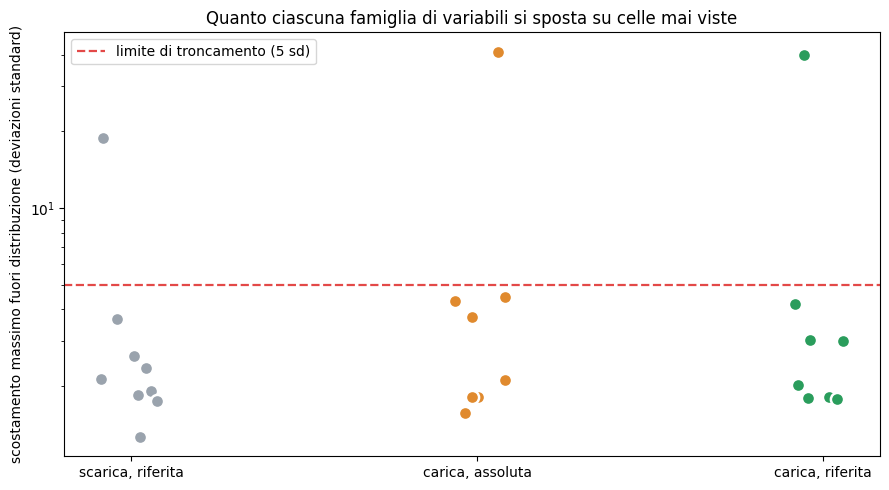

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

ordine = ["scarica, riferita", "carica, assoluta", "carica, riferita"]
colori = {"scarica, riferita": "#9aa3ad", "carica, assoluta": "#e08a2e",
          "carica, riferita": "#2a9d5c"}

for i, famiglia in enumerate(ordine):
    sotto = trasferibilita[trasferibilita.famiglia == famiglia]
    if not len(sotto):
        continue
    rng = np.random.default_rng(i)
    ax.scatter(i + rng.uniform(-0.09, 0.09, len(sotto)),
               sotto.z_massimo_fuori_distribuzione,
               s=90, color=colori[famiglia], edgecolor="white", linewidth=1.8, zorder=3)

ax.axhline(LIMITE_SCOSTAMENTO, color="#e34948", ls="--", lw=1.6,
           label=f"limite di troncamento ({LIMITE_SCOSTAMENTO:.0f} sd)")
ax.set_xticks(range(len(ordine)))
ax.set_xticklabels(ordine)
ax.set_yscale("log")
ax.set_ylabel("scostamento massimo fuori distribuzione (deviazioni standard)")
ax.set_title("Quanto ciascuna famiglia di variabili si sposta su celle mai viste")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "08_trasferibilita.png", dpi=200, bbox_inches="tight")
plt.show()


## 4. Il compito: stimare il SoH senza misurarlo

Ogni esempio è una finestra di dieci cicli consecutivi e validi dello stesso blocco, e il
valore da stimare è il SoH del **ciclo finale della finestra**. Non è una previsione ma una
stima: si osserva la storia recente e si dice in che stato è la cella adesso.

**Cosa non entra fra gli ingressi**, ed è il punto che rende il compito onesto:

- `capacity`, perché il SoH ne è il rapporto con il valore iniziale: darla in ingresso
  sarebbe dare la risposta;
- `soh_feature`, cioè il SoH dei cicli passati, per la stessa ragione.

**Il riferimento da battere.** Senza un valore precedente da ripetere la persistenza non
esiste, quindi il riferimento diventa la previsione costante migliore: la media del SoH
sull'insieme di addestramento. È un riferimento debole in assoluto, ma è l'unico
disponibile a chi non misuri nulla, ed è esattamente la condizione di partenza del
problema.

**Le tre configurazioni sono valutate sulle stesse finestre.** I cicli in cui manca un
indicatore di ricarica sono più numerosi di quelli in cui manca un descrittore di scarica:
se ciascuna configurazione usasse tutti i cicli a sua disposizione, la differenza fra loro
mescolerebbe la qualità delle variabili con quella dei cicli su cui vengono misurate. Il
confronto viene quindi ristretto ai cicli in cui **tutte** le variabili sono definite.


In [7]:
from sklearn.preprocessing import StandardScaler

CONFIGURAZIONI = {
    "solo carica": CARICA_REL,
    "solo scarica": SCARICA_REL,
    "carica + scarica": CARICA_REL + SCARICA_REL,
}


# Le tre configurazioni vanno confrontate sulle STESSE finestre. I cicli in cui manca un
# indicatore di ricarica sono più di quelli in cui manca un descrittore di scarica: se
# ciascuna configurazione usasse quello che ha, la differenza fra loro mescolerebbe la
# qualità delle variabili con quella dei cicli su cui vengono valutate.
COLONNE_RICHIESTE = sorted(set(CARICA_REL) | set(SCARICA_REL))
righe_complete = df[COLONNE_RICHIESTE].notna().all(axis=1)

print(f"Cicli con tutte le variabili disponibili: {int((righe_complete & df.is_valid).sum())} "
      f"su {int(df.is_valid.sum())} validi")
scartati = int((~righe_complete & df.is_valid).sum())
if scartati:
    print(f"{scartati} cicli esclusi dal confronto perché manca almeno una variabile.")
    print("Sono quasi tutti cicli in cui la ricarica non attraversa l'intera finestra di")
    print("tensione, quindi il tempo in corrente costante non è definito.")


def prepara(colonne):
    """Normalizza sull'addestramento e costruisce le finestre; bersaglio: SoH finale."""
    dati = df[righe_complete].copy()
    addestramento = dati[dati.protocol_block.isin(SPLIT["train"]) & dati.is_valid]
    scaler = StandardScaler().fit(addestramento[colonne])
    dati[colonne] = np.clip(scaler.transform(dati[colonne]),
                            -LIMITE_SCOSTAMENTO, LIMITE_SCOSTAMENTO)

    insiemi = {}
    for nome, blocchi in SPLIT.items():
        X, y, blocco = [], [], []
        for identificativo in blocchi:
            gruppo = dati[(dati.protocol_block == identificativo) & dati.is_valid]
            gruppo = gruppo.sort_values("discharge_cycle")
            numerazione = gruppo.discharge_cycle.to_numpy()
            apre = np.ones(len(gruppo), dtype=bool)
            apre[1:] = np.diff(numerazione) != 1
            for _, tratto in gruppo.groupby(np.cumsum(apre)):
                valori = tratto[colonne].to_numpy()
                soh = tratto["soh"].to_numpy()
                for i in range(len(tratto) - WINDOW_SIZE + 1):
                    X.append(valori[i:i + WINDOW_SIZE])
                    y.append(soh[i + WINDOW_SIZE - 1])
                    blocco.append(identificativo)
        insiemi[nome] = (np.asarray(X, "float32"), np.asarray(y, "float32"),
                         np.asarray(blocco))
    return insiemi


def rmse(vero, previsto):
    return float(np.sqrt(np.mean((np.asarray(previsto) - np.asarray(vero)) ** 2)))


def skill_score(vero, previsto, baseline):
    mse_modello = np.mean((np.asarray(previsto) - np.asarray(vero)) ** 2)
    mse_baseline = np.mean((np.asarray(baseline) - np.asarray(vero)) ** 2)
    return float(1.0 - mse_modello / mse_baseline) if mse_baseline else np.nan


dati_per_configurazione = {nome: prepara(colonne)
                           for nome, colonne in CONFIGURAZIONI.items()}

for nome, insiemi in dati_per_configurazione.items():
    conteggi = "   ".join(f"{k} {len(v[1])}" for k, v in insiemi.items())
    print(f"{nome:18s} {len(CONFIGURAZIONI[nome]):2d} variabili   {conteggi}")


Cicli con tutte le variabili disponibili: 902 su 926 validi
24 cicli esclusi dal confronto perché manca almeno una variabile.
Sono quasi tutti cicli in cui la ricarica non attraversa l'intera finestra di
tensione, quindi il tempo in corrente costante non è definito.
solo carica         8 variabili   train 296   validation 148   test_id 144   test_ood 131
solo scarica        9 variabili   train 296   validation 148   test_id 144   test_ood 131
carica + scarica   17 variabili   train 296   validation 148   test_id 144   test_ood 131


In [8]:
riferimento = dati_per_configurazione["solo carica"]
media_addestramento = float(riferimento["train"][1].mean())

baseline = pd.DataFrame([{
    "insieme": nome,
    "n_finestre": len(y),
    "soh_minimo": float(y.min()), "soh_massimo": float(y.max()),
    "baseline_media_RMSE": rmse(y, np.full(len(y), media_addestramento)),
} for nome, (X, y, b) in riferimento.items()])

display(baseline.round(4))
print(f"Media del SoH in addestramento: {media_addestramento:.4f}")
print("È la stima costante migliore per chi non osservi nulla della cella.")


,insieme,n_finestre,soh_minimo,soh_massimo,baseline_media_RMSE
0,train,296,0.5731,1.0066,0.1148
1,validation,148,0.7447,1.0004,0.1039
2,test_id,144,0.7290,0.9910,0.1051
3,test_ood,131,0.7951,0.9896,0.1445


Media del SoH in addestramento: 0.7934
È la stima costante migliore per chi non osservi nulla della cella.


## 5. Un riferimento interpretabile prima della rete

Prima di addestrare una rete conviene stabilire quanto si ottenga con una **regressione
lineare su un solo indicatore**. Serve a due cose: dà un termine di paragone onesto, e
rende verificabile che il segnale sia dove la fisica dice che debba essere.

Se una retta su una sola variabile arrivasse vicino alla rete, la rete non starebbe
aggiungendo granché — ed è un'informazione che vale la pena avere.


In [9]:
def regressione_singola(colonna):
    """Retta ai minimi quadrati SoH ~ indicatore, stimata sull'addestramento."""
    dati = df[df.is_valid & righe_complete]
    addestramento = dati[dati.protocol_block.isin(SPLIT["train"])]
    if addestramento[colonna].std() < 1e-12:
        return None

    pendenza, intercetta = np.polyfit(addestramento[colonna], addestramento.soh, 1)
    riga = {"variabile": colonna}
    for nome, blocchi in SPLIT.items():
        sotto = dati[dati.protocol_block.isin(blocchi)]
        previsto = pendenza * sotto[colonna] + intercetta
        riga[nome] = rmse(sotto.soh, previsto)
    return riga


righe = [regressione_singola(c) for c in CARICA_REL]
regressioni = pd.DataFrame([r for r in righe if r]).sort_values("test_id")
display(regressioni.round(4))

migliore_singola = regressioni.iloc[0]
print(f"\nMigliore indicatore singolo: {migliore_singola.variabile}")
print(f"  RMSE {migliore_singola.test_id:.4f} in distribuzione, "
      f"{migliore_singola.test_ood:.4f} fuori, contro "
      f"{float(baseline.set_index('insieme').loc['test_id', 'baseline_media_RMSE']):.4f} "
      f"della media")


,variabile,train,validation,test_id,test_ood
3,cc_time_3v8_4v1_s_rel,0.0383,0.0446,0.0503,0.0384
5,charge_cc_ah_rel,0.0412,0.0389,0.0588,0.0373
0,cc_duration_s_rel,0.0441,0.0402,0.0625,0.0387
2,cv_time_fraction_rel,0.0461,0.0536,0.0673,0.0666
4,charge_throughput_ah_rel,0.0453,0.0434,0.0686,0.0516
1,cv_duration_s_rel,0.0473,0.0394,0.0688,0.0711
6,ica_peak_height_rel,0.0234,0.0340,0.1033,0.6569
7,ica_peak_voltage_rel,0.0662,0.0747,0.1184,0.0869



Migliore indicatore singolo: cc_time_3v8_4v1_s_rel
  RMSE 0.0503 in distribuzione, 0.0384 fuori, contro 0.1051 della media


### L'interpretazione fisica

Gli indicatori che emergono appartengono tutti alla stessa famiglia, e la ragione è una
sola.

`cc_time_3v8_4v1_s` è il tempo impiegato ad attraversare la finestra fra 3.8 e 4.1 V nella
fase a corrente costante. `charge_cc_ah` è la carica accumulata nella stessa fase. A
corrente costante le due sono **la stessa grandezza**, perché la carica è la corrente per
il tempo e la corrente è fissa: sono due modi di misurare quanta carica la cella accetta
in quell'intervallo di tensione.

E quella è una misura di capacità ottenuta **senza scaricare nulla**. Riferita al proprio
valore di inizio vita diventa il rapporto fra la carica che la cella accetta oggi e quella
che accettava da nuova — cioè esattamente ciò che il SoH esprime sulla scarica. Non è
quindi un indicatore correlato al SoH per caso: è la definizione di SoH trasposta sulla
sola fase del ciclo che in servizio si può osservare.

`cv_duration_s` e `cv_time_fraction` misurano il fenomeno complementare: la coda a tensione
costante si allunga quando la resistenza interna cresce. Portano informazione sullo stesso
stato per una via diversa, ed è il motivo per cui i due gruppi si sostituiscono a vicenda.

**Questo spiega una discordanza che comparirà nella sezione seguente.** La regressione su
una sola variabile e la permutation importance possono indicare indicatori diversi, e non è
una contraddizione: la prima misura quanta informazione una variabile contiene **da sola**,
la seconda quanto il modello **vi si appoggia** avendo anche le altre. Fra due variabili
che misurano la stessa cosa, il modello ne usa una e l'altra diventa ridondante — permutarla
non cambia nulla, ma da sola sarebbe stata altrettanto buona.


## 6. La rete sulle tre configurazioni

Una sola architettura, la stessa della pipeline principale, addestrata su ciascuno dei tre
insiemi di variabili. Tre semi per configurazione.

A differenza del notebook 03 il bersaglio è il SoH stesso e non la sua variazione: qui non
c'è un ultimo valore osservato a cui sommare qualcosa, perché il SoH non è fra gli
ingressi. L'ultimo strato parte quindi dalla media di addestramento.


In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

ARCHITETTURA = "GRU"
UNITA, UNITA_DENSA, DROPOUT = 64, 32, 0.2
SEMI = [0, 1, 2]
EPOCHE, BATCH_SIZE, PAZIENZA = 200, 32, 25


def costruisci(forma, bias_iniziale):
    ingresso = layers.Input(shape=forma)
    strato = {"SimpleRNN": layers.SimpleRNN, "LSTM": layers.LSTM,
              "GRU": layers.GRU}[ARCHITETTURA]
    x = strato(UNITA)(ingresso)
    x = layers.Dropout(DROPOUT)(x)
    x = layers.Dense(UNITA_DENSA, activation="relu")(x)
    return models.Model(ingresso, layers.Dense(
        1, bias_initializer=tf.keras.initializers.Constant(bias_iniziale))(x))


def addestra_stima(insiemi, semi=SEMI):
    Xtr, ytr, _ = insiemi["train"]
    Xva, yva, _ = insiemi["validation"]
    media = float(ytr.mean())

    righe, modelli = [], []
    for seme in semi:
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(seme)

        modello = costruisci(Xtr.shape[1:], media)
        modello.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
        modello.fit(Xtr, ytr, validation_data=(Xva, yva),
                    epochs=EPOCHE, batch_size=BATCH_SIZE, verbose=0,
                    callbacks=[callbacks.EarlyStopping(monitor="val_loss",
                                                       patience=PAZIENZA,
                                                       restore_best_weights=True)])
        modelli.append(modello)

        for nome, (X, y, _) in insiemi.items():
            previsto = modello.predict(X, verbose=0).reshape(-1)
            costante = np.full(len(y), media)
            righe.append({"seme": seme, "insieme": nome, "n_finestre": len(y),
                          "RMSE": rmse(y, previsto),
                          "MAE": float(np.mean(np.abs(previsto - y))),
                          "SS": skill_score(y, previsto, costante)})
    return pd.DataFrame(righe), modelli


In [11]:
risultati, modelli_per_configurazione = [], {}
for nome, insiemi in dati_per_configurazione.items():
    tabella, modelli = addestra_stima(insiemi)
    tabella["configurazione"] = nome
    tabella["n_variabili"] = len(CONFIGURAZIONI[nome])
    risultati.append(tabella)
    modelli_per_configurazione[nome] = modelli

    sotto = tabella[tabella.insieme.isin(["test_id", "test_ood"])]
    valori = sotto.groupby("insieme").RMSE.median()
    print(f"{nome:18s} test_id {valori['test_id']:.4f}   "
          f"test_ood {valori['test_ood']:.4f}")

stima = pd.concat(risultati, ignore_index=True)
stima.to_csv(TABLES_DIR / "08_carica_stima.csv", index=False)


solo carica        test_id 0.0421   test_ood 0.0526
solo scarica       test_id 0.0524   test_ood 0.0514
carica + scarica   test_id 0.0857   test_ood 0.1233


In [12]:
riepilogo_stima = (stima.groupby(["configurazione", "insieme"])
                   .agg(n_variabili=("n_variabili", "first"),
                        n_finestre=("n_finestre", "first"),
                        RMSE=("RMSE", "median"), RMSE_min=("RMSE", "min"),
                        RMSE_max=("RMSE", "max"), MAE=("MAE", "median"),
                        SS=("SS", "median"))
                   .reset_index())

for insieme in ["validation", "test_id", "test_ood"]:
    print(f"\n{insieme}   (baseline media: "
          f"{float(baseline.set_index('insieme').loc[insieme, 'baseline_media_RMSE']):.4f})")
    display(riepilogo_stima[riepilogo_stima.insieme == insieme]
            .drop(columns="insieme").round(4))

riepilogo_stima.to_csv(TABLES_DIR / "08_carica_stima_riepilogo.csv", index=False)



validation   (baseline media: 0.1039)


,configurazione,n_variabili,n_finestre,RMSE,RMSE_min,RMSE_max,MAE,SS
3,carica + scarica,17,148,0.0930,0.0405,0.0999,0.0777,0.1987
7,solo carica,8,148,0.0149,0.0146,0.0182,0.0126,0.9793
11,solo scarica,9,148,0.0293,0.0272,0.0407,0.0238,0.9206



test_id   (baseline media: 0.1051)


,configurazione,n_variabili,n_finestre,RMSE,RMSE_min,RMSE_max,MAE,SS
0,carica + scarica,17,144,0.0857,0.0464,0.2468,0.0707,0.3355
4,solo carica,8,144,0.0421,0.0395,0.0503,0.0287,0.8395
8,solo scarica,9,144,0.0524,0.0517,0.0561,0.0469,0.7509



test_ood   (baseline media: 0.1445)


,configurazione,n_variabili,n_finestre,RMSE,RMSE_min,RMSE_max,MAE,SS
1,carica + scarica,17,131,0.1233,0.0438,0.1797,0.0854,0.2727
5,solo carica,8,131,0.0526,0.0260,0.0819,0.0197,0.8677
9,solo scarica,9,131,0.0514,0.0464,0.0587,0.0409,0.8735


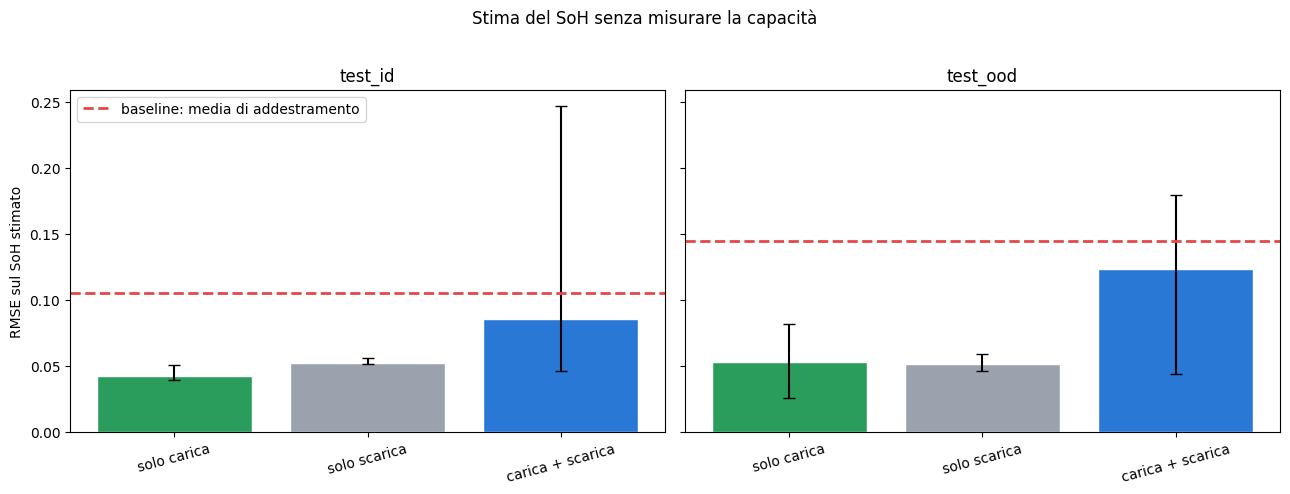

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)

configurazioni = list(CONFIGURAZIONI)
colori = ["#2a9d5c", "#9aa3ad", "#2a78d6"]

for ax, insieme in zip(axes, ["test_id", "test_ood"]):
    valori = [riepilogo_stima[(riepilogo_stima.configurazione == c)
                              & (riepilogo_stima.insieme == insieme)].RMSE.iloc[0]
              for c in configurazioni]
    minimi = [riepilogo_stima[(riepilogo_stima.configurazione == c)
                              & (riepilogo_stima.insieme == insieme)].RMSE_min.iloc[0]
              for c in configurazioni]
    massimi = [riepilogo_stima[(riepilogo_stima.configurazione == c)
                               & (riepilogo_stima.insieme == insieme)].RMSE_max.iloc[0]
               for c in configurazioni]
    errori = [np.array(valori) - np.array(minimi), np.array(massimi) - np.array(valori)]

    ax.bar(range(len(configurazioni)), valori, yerr=errori, capsize=4,
           color=colori, edgecolor="white")
    riferimento_media = float(
        baseline.set_index("insieme").loc[insieme, "baseline_media_RMSE"])
    ax.axhline(riferimento_media, color="#e34948", ls="--", lw=2,
               label="baseline: media di addestramento")
    ax.set_xticks(range(len(configurazioni)))
    ax.set_xticklabels(configurazioni, rotation=15)
    ax.set_title(insieme)

axes[0].set_ylabel("RMSE sul SoH stimato")
axes[0].legend()
fig.suptitle("Stima del SoH senza misurare la capacità", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "08_stima_configurazioni.png", dpi=200, bbox_inches="tight")
plt.show()


## 7. Quale indicatore porta il segnale

Permutation importance sul modello addestrato con i soli indicatori di ricarica: si permuta
una variabile fra le finestre, lasciando tutto il resto invariato, e si misura di quanto
cresce l'errore.

La stessa permutazione viene applicata a tutti i passi della finestra, perché la variabile
è una sola grandezza osservata dieci volte e non dieci variabili distinte.


In [14]:
N_PERMUTAZIONI = 20

insiemi_carica = dati_per_configurazione["solo carica"]
modello_carica = modelli_per_configurazione["solo carica"][0]


def permutation_importance(modello, X, y, colonne, n_permutazioni=N_PERMUTAZIONI, seme=0):
    rng = np.random.default_rng(seme)
    base = rmse(y, modello.predict(X, verbose=0).reshape(-1))

    righe = []
    for j, nome_variabile in enumerate(colonne):
        aumenti = []
        for _ in range(n_permutazioni):
            Xp = X.copy()
            Xp[:, :, j] = X[rng.permutation(len(X)), :, j]
            aumenti.append(rmse(y, modello.predict(Xp, verbose=0).reshape(-1)) - base)
        righe.append({"variabile": nome_variabile,
                      "aumento_medio": float(np.mean(aumenti)),
                      "aumento_sd": float(np.std(aumenti))})
    return base, pd.DataFrame(righe).sort_values("aumento_medio", ascending=False)


X_id, y_id, _ = insiemi_carica["test_id"]
base_id, importanza = permutation_importance(modello_carica, X_id, y_id, CARICA_REL)
importanza["aumento_relativo"] = importanza.aumento_medio / base_id

display(importanza.round(4))
importanza.to_csv(TABLES_DIR / "08_carica_importanza.csv", index=False)
print(f"RMSE senza permutazioni: {base_id:.4f}")


,variabile,aumento_medio,aumento_sd,aumento_relativo
5,charge_cc_ah_rel,0.0543,0.0062,1.0810
4,charge_throughput_ah_rel,0.0149,0.0040,0.2961
0,cc_duration_s_rel,0.0131,0.0027,0.2603
2,cv_time_fraction_rel,0.0117,0.0019,0.2337
1,cv_duration_s_rel,0.0112,0.0020,0.2224
6,ica_peak_height_rel,0.0108,0.0029,0.2156
3,cc_time_3v8_4v1_s_rel,0.0011,0.0021,0.0223
7,ica_peak_voltage_rel,-0.0111,0.0026,-0.2201


RMSE senza permutazioni: 0.0503


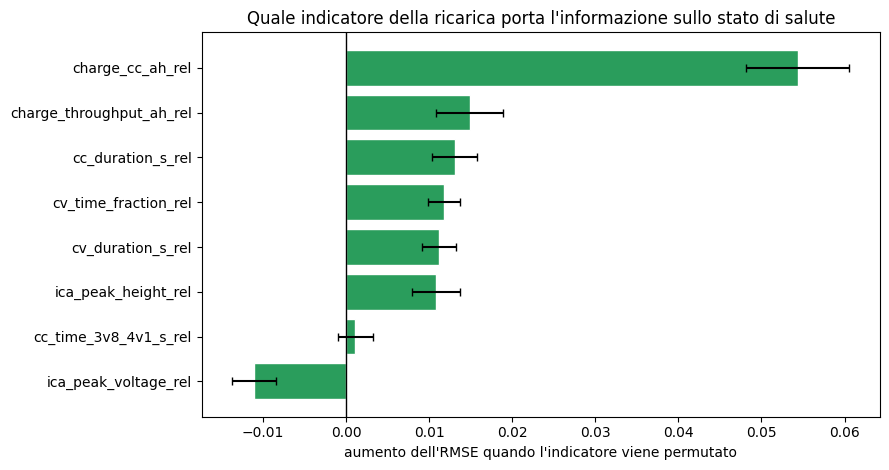

In [15]:
fig, ax = plt.subplots(figsize=(9, 4.8))

ordinata = importanza.sort_values("aumento_medio")
posizioni = np.arange(len(ordinata))
ax.barh(posizioni, ordinata.aumento_medio, xerr=ordinata.aumento_sd,
        color="#2a9d5c", edgecolor="white", capsize=3)
ax.set_yticks(posizioni)
ax.set_yticklabels(ordinata.variabile)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("aumento dell'RMSE quando l'indicatore viene permutato")
ax.set_title("Quale indicatore della ricarica porta l'informazione sullo stato di salute")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "08_importanza_indicatori.png", dpi=200, bbox_inches="tight")
plt.show()


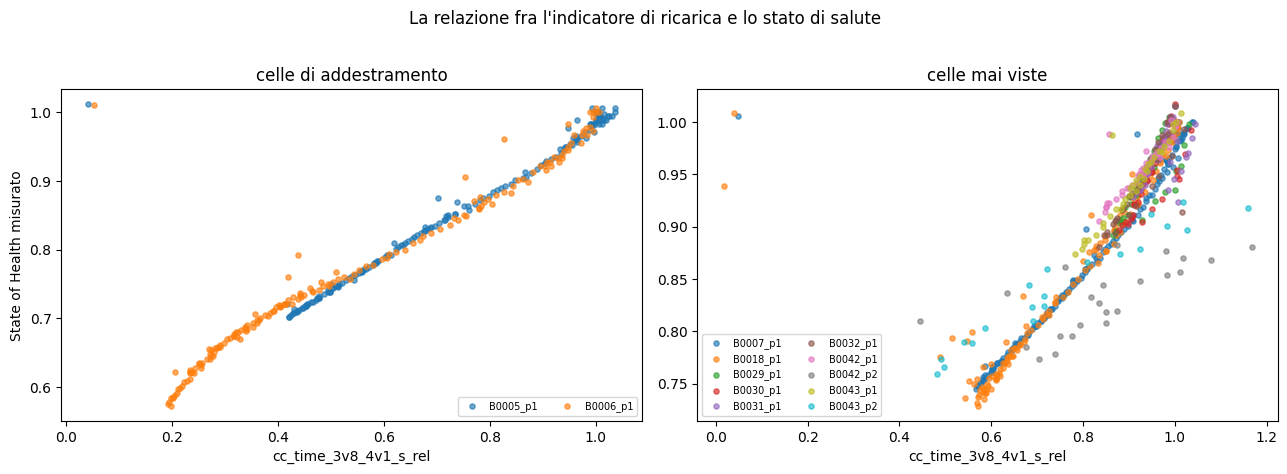

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

variabile_migliore = migliore_singola.variabile
dati_grafico = df[df.is_valid & righe_complete]

for ax, (titolo, selezione) in zip(axes, [
    ("celle di addestramento", dati_grafico.protocol_block.isin(SPLIT["train"])),
    ("celle mai viste", ~dati_grafico.protocol_block.isin(SPLIT["train"])),
]):
    sotto = dati_grafico[selezione]
    for blocco, gruppo in sotto.groupby("protocol_block"):
        ax.scatter(gruppo[variabile_migliore], gruppo.soh, s=14, alpha=0.65, label=blocco)
    ax.set_xlabel(variabile_migliore)
    ax.set_title(titolo)
    ax.legend(fontsize=7, ncol=2)

axes[0].set_ylabel("State of Health misurato")
fig.suptitle("La relazione fra l'indicatore di ricarica e lo stato di salute", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "08_relazione_indicatore_soh.png", dpi=200, bbox_inches="tight")
plt.show()


## 8. La ricarica migliora anche il compito della pipeline principale?

Domanda diversa dalle precedenti. Qui si torna al compito del notebook 03 — prevedere il
SoH del ciclo successivo, con il SoH dei cicli passati fra gli ingressi — e si verifica se
aggiungere gli indicatori di ricarica cambi qualcosa.

L'attesa è che serva poco: in quel compito il SoH corrente è già nell'ingresso, e gli
indicatori di ricarica portano informazione **sullo stesso stato**, non su come evolverà.
La verifica serve a stabilirlo con un numero invece che per argomento.


In [17]:
ORIZZONTE_PRINCIPALE = 1


def prepara_previsione(colonne):
    """Come nella pipeline principale: bersaglio il SoH del ciclo successivo."""
    # Stesso vincolo della sezione precedente: le due configurazioni vanno confrontate
    # sulle stesse finestre.
    dati = df[righe_complete].copy()
    addestramento = dati[dati.protocol_block.isin(SPLIT["train"]) & dati.is_valid]
    scaler = StandardScaler().fit(addestramento[colonne])
    dati[colonne] = np.clip(scaler.transform(dati[colonne]),
                            -LIMITE_SCOSTAMENTO, LIMITE_SCOSTAMENTO)

    insiemi = {}
    for nome, blocchi in SPLIT.items():
        X, y, ultimo = [], [], []
        for identificativo in blocchi:
            gruppo = dati[(dati.protocol_block == identificativo) & dati.is_valid]
            gruppo = gruppo.sort_values("discharge_cycle")
            numerazione = gruppo.discharge_cycle.to_numpy()
            apre = np.ones(len(gruppo), dtype=bool)
            apre[1:] = np.diff(numerazione) != 1
            for _, tratto in gruppo.groupby(np.cumsum(apre)):
                valori = tratto[colonne].to_numpy()
                soh = tratto["soh"].to_numpy()
                for i in range(len(tratto) - WINDOW_SIZE - ORIZZONTE_PRINCIPALE + 1):
                    fine = i + WINDOW_SIZE - 1
                    X.append(valori[i:i + WINDOW_SIZE])
                    y.append(soh[fine + ORIZZONTE_PRINCIPALE])
                    ultimo.append(soh[fine])
        insiemi[nome] = (np.asarray(X, "float32"), np.asarray(y, "float32"),
                         np.asarray(ultimo, "float32"))
    return insiemi


# Qui il SoH passato torna fra gli ingressi: è il compito del notebook 03.
CONFIGURAZIONI_PRINCIPALI = {
    "scarica": ["soh_feature"] + SCARICA_REL,
    "carica + scarica": ["soh_feature"] + SCARICA_REL + CARICA_REL,
}


def addestra_previsione(insiemi, semi=SEMI):
    Xtr, ytr, ltr = insiemi["train"]
    Xva, yva, lva = insiemi["validation"]
    variazione_train, variazione_val = ytr - ltr, yva - lva

    righe = []
    for seme in semi:
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(seme)

        modello = costruisci(Xtr.shape[1:], float(variazione_train.mean()))
        modello.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
        modello.fit(Xtr, variazione_train, validation_data=(Xva, variazione_val),
                    epochs=EPOCHE, batch_size=BATCH_SIZE, verbose=0,
                    callbacks=[callbacks.EarlyStopping(monitor="val_loss",
                                                       patience=PAZIENZA,
                                                       restore_best_weights=True)])

        for nome, (X, y, ultimo) in insiemi.items():
            previsto = modello.predict(X, verbose=0).reshape(-1) + ultimo
            righe.append({"seme": seme, "insieme": nome, "n_finestre": len(y),
                          "RMSE": rmse(y, previsto),
                          "SS": skill_score(y, previsto, ultimo),
                          "persistenza_RMSE": rmse(y, ultimo)})
    return pd.DataFrame(righe)


In [18]:
righe_principale = []
for nome, colonne in CONFIGURAZIONI_PRINCIPALI.items():
    insiemi = prepara_previsione(colonne)
    tabella = addestra_previsione(insiemi)
    tabella["configurazione"] = nome
    tabella["n_variabili"] = len(colonne)
    righe_principale.append(tabella)

    sotto = tabella[tabella.insieme == "test_id"]
    print(f"{nome:18s} {len(colonne):2d} variabili   "
          f"RMSE test_id {sotto.RMSE.median():.5f}   "
          f"skill score {sotto.SS.median():+.3f}")

principale = pd.concat(righe_principale, ignore_index=True)
principale.to_csv(TABLES_DIR / "08_carica_su_compito_principale.csv", index=False)

riepilogo_principale = (principale.groupby(["configurazione", "insieme"])
                        .agg(n_variabili=("n_variabili", "first"),
                             RMSE=("RMSE", "median"), SS=("SS", "median"),
                             persistenza=("persistenza_RMSE", "first"))
                        .reset_index())
display(riepilogo_principale.round(5))


scarica            10 variabili   RMSE test_id 0.01844   skill score -1.621
carica + scarica   18 variabili   RMSE test_id 0.02728   skill score -4.734


,configurazione,insieme,n_variabili,RMSE,SS,persistenza
0,carica + scarica,test_id,18,0.02728,-4.73371,0.01139
1,carica + scarica,test_ood,18,0.03461,-16.64335,0.00824
2,carica + scarica,train,18,0.00861,0.21968,0.00974
3,carica + scarica,validation,18,0.02077,-8.54535,0.00672
4,scarica,test_id,10,0.01844,-1.62060,0.01139
5,scarica,test_ood,10,0.02192,-6.07816,0.00824
6,scarica,train,10,0.01075,-0.21851,0.00974
7,scarica,validation,10,0.02440,-12.17901,0.00672


In [19]:
confronto = riepilogo_principale.pivot(index="insieme", columns="configurazione",
                                       values="RMSE")
confronto["variazione"] = (confronto["carica + scarica"] / confronto["scarica"] - 1)
display(confronto.round(5))

print("Lettura: valori positivi nella colonna `variazione` indicano che aggiungere gli")
print("indicatori di ricarica peggiora, negativi che migliora.")


configurazione,carica + scarica,scarica,variazione
insieme,,,
test_id,0.02728,0.01844,0.47917
test_ood,0.03461,0.02192,0.57881
train,0.00861,0.01075,-0.19976
validation,0.02077,0.02440,-0.14895


Lettura: valori positivi nella colonna `variazione` indicano che aggiungere gli
indicatori di ricarica peggiora, negativi che migliora.


## 9. Conclusioni


In [20]:
stima_id = riepilogo_stima[(riepilogo_stima.insieme == "test_id")].set_index("configurazione")
stima_ood = riepilogo_stima[(riepilogo_stima.insieme == "test_ood")].set_index("configurazione")
media_id = float(baseline.set_index("insieme").loc["test_id", "baseline_media_RMSE"])
media_ood = float(baseline.set_index("insieme").loc["test_ood", "baseline_media_RMSE"])

print("1. Si può stimare il SoH dalla sola ricarica, senza misurare la capacità\n")
print(f"   RMSE {stima_id.loc['solo carica', 'RMSE']:.4f} su celle mai viste, contro "
      f"{media_id:.4f} della stima costante: una riduzione del "
      f"{1 - stima_id.loc['solo carica', 'RMSE'] / media_id:.0%}.")
print(f"   Fuori distribuzione {stima_ood.loc['solo carica', 'RMSE']:.4f} contro "
      f"{media_ood:.4f}.")
print()

print("2. Confronto fra le fonti di informazione\n")
for configurazione in CONFIGURAZIONI:
    print(f"   {configurazione:18s} test_id {stima_id.loc[configurazione, 'RMSE']:.4f}   "
          f"test_ood {stima_ood.loc[configurazione, 'RMSE']:.4f}")
differenza_ood = (stima_ood.loc["solo scarica", "RMSE"]
                  - stima_ood.loc["solo carica", "RMSE"])
if differenza_ood > 0.005:
    print("\n   Fuori distribuzione la ricarica batte la scarica: il protocollo di carica")
    print("   impostato è lo stesso per tutte le celle, quello di scarica no.")
elif abs(differenza_ood) <= 0.005:
    print("\n   Fuori distribuzione le due fonti sono equivalenti, e l'ipotesi della")
    print("   sezione 3 non è confermata nella forma in cui era stata posta. La lettura")
    print("   corretta è che a rendere trasferibili le variabili non è la fase del ciclo")
    print("   da cui provengono, ma il riferimento all'inizio vita: applicato a entrambe")
    print("   le famiglie, porta entrambe entro poche deviazioni standard. Il vantaggio")
    print("   della ricarica resta in distribuzione, e soprattutto è operativo: non")
    print("   richiede di scaricare la cella.")
else:
    print("\n   Fuori distribuzione la scarica batte la ricarica: l'ipotesi della sezione 3")
    print("   non è confermata.")
print()

print("3. L'informazione sta in un solo indicatore\n")
print(f"   Una retta su {migliore_singola.variabile} da sola dà RMSE "
      f"{migliore_singola.test_id:.4f} in distribuzione e "
      f"{migliore_singola.test_ood:.4f} fuori.")
print("   È il tempo per attraversare una finestra di tensione a corrente costante,")
print("   rapportato al proprio valore da cella nuova: cioè la carica accumulata oggi")
print("   su quella accumulata da nuova. È la definizione di SoH trasposta sulla fase")
print("   del ciclo che in servizio si può osservare.")
print()

variazione_id = float(confronto.loc["test_id", "variazione"])
print("4. Sul compito della pipeline principale la ricarica aggiunge poco\n")
print(f"   RMSE {variazione_id:+.1%} aggiungendo gli indicatori di ricarica.")
print("   Coerente con l'attesa: in quel compito il SoH corrente è già negli ingressi,")
print("   e la ricarica descrive lo stesso stato, non la sua evoluzione futura.")
print()

print("Limiti\n")
print("   - la stima richiede una ricarica completa fino a fine tensione: cariche")
print("     parziali non attraversano la finestra su cui l'indicatore è definito;")
print("   - il riferimento di inizio vita presuppone di aver osservato la cella da nuova;")
print("   - i blocchi fuori distribuzione coprono un intervallo di SoH stretto, quindi")
print("     il confronto su di essi è meno informativo di quello in distribuzione;")
print("   - resta il confondimento fra temperatura e corrente già dichiarato altrove.")


1. Si può stimare il SoH dalla sola ricarica, senza misurare la capacità

   RMSE 0.0421 su celle mai viste, contro 0.1051 della stima costante: una riduzione del 60%.
   Fuori distribuzione 0.0526 contro 0.1445.

2. Confronto fra le fonti di informazione

   solo carica        test_id 0.0421   test_ood 0.0526
   solo scarica       test_id 0.0524   test_ood 0.0514
   carica + scarica   test_id 0.0857   test_ood 0.1233

   Fuori distribuzione le due fonti sono equivalenti, e l'ipotesi della
   sezione 3 non è confermata nella forma in cui era stata posta. La lettura
   corretta è che a rendere trasferibili le variabili non è la fase del ciclo
   da cui provengono, ma il riferimento all'inizio vita: applicato a entrambe
   le famiglie, porta entrambe entro poche deviazioni standard. Il vantaggio
   della ricarica resta in distribuzione, e soprattutto è operativo: non
   richiede di scaricare la cella.

3. L'informazione sta in un solo indicatore

   Una retta su cc_time_3v8_4v1_s_rel da 

In [21]:
prodotti = sorted(list(TABLES_DIR.glob("08_*.csv")) + list(FIGURES_DIR.glob("08_*.png")))
for percorso in prodotti:
    print("  ", percorso.relative_to(PROJECT_ROOT))
print(f"\n{len(prodotti)} file prodotti da questo notebook.")


   results/figures/08_importanza_indicatori.png
   results/figures/08_relazione_indicatore_soh.png
   results/figures/08_stima_configurazioni.png
   results/figures/08_trasferibilita.png
   results/tables/08_carica_importanza.csv
   results/tables/08_carica_stima.csv
   results/tables/08_carica_stima_riepilogo.csv
   results/tables/08_carica_su_compito_principale.csv
   results/tables/08_carica_trasferibilita.csv

9 file prodotti da questo notebook.
